In [2]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")

 All libraries imported successfully!
NumPy version: 2.4.6
Pandas version: 3.0.5
Seaborn version: 0.13.2


In [3]:
# Load the tips dataset from seaborn
# Source: https://github.com/mwaskom/seaborn-data/blob/master/tips.csv
# License: BSD 3-Clause
# Why chosen: Perfect mix of numeric and categorical columns, good size (244 rows)

df = sns.load_dataset('tips')

# Save a copy to raw folder for reference
df.to_csv('../data/raw/tips.csv', index=False)

print("=" * 60)
print("TASK 1: DATASET SCHEMA REPORT")
print("=" * 60)

print(f"\n Dataset Shape: {df.shape}")
print(f"   - {df.shape[0]} rows")
print(f"   - {df.shape[1]} columns")

print(f"\n Column Names:")
print(df.columns.tolist())

print(f"\n Data Types:")
print(df.dtypes)

print(f"\n Null Counts per Column:")
print(df.isna().sum())

print(f"\n Unique Value Counts per Column:")
print(df.nunique())

print("\n First 5 rows:")
df.head()

TASK 1: DATASET SCHEMA REPORT

 Dataset Shape: (244, 7)
   - 244 rows
   - 7 columns

 Column Names:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

 Data Types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

 Null Counts per Column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

 Unique Value Counts per Column:
total_bill    229
tip           123
sex             2
smoker          2
day             4
time            2
size            6
dtype: int64

 First 5 rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
print("=" * 60)
print("TASK 2: DATA CLEANING")
print("=" * 60)

# Check for missing values
print("\n Checking for missing values...")
null_counts = df.isna().sum()
print(f"Total missing values: {null_counts.sum()}")

# Handle missing values - If any exist
# For tips dataset, there are no missing values, but here's how we'd handle them:
# Strategy: Since this dataset has no nulls, we'll document that
# If there were nulls, we would:
# - For numeric: impute with median (robust to outliers)
# - For categorical: impute with mode (most frequent value)

if null_counts.sum() == 0:
    print(" No missing values found! Dataset is clean.")
else:
    # Example of how to handle if there were nulls
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"   - Imputed {col} with median: {df[col].median()}")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"   - Imputed {col} with mode: {df[col].mode()[0]}")

TASK 2: DATA CLEANING

 Checking for missing values...
Total missing values: 0
 No missing values found! Dataset is clean.


In [5]:
# Fix any data type issues
print("\n Checking and fixing data types...")

# Before fixing
print("Before fixing dtypes:")
print(df.dtypes)

# Convert appropriate columns to categorical
# 'sex', 'smoker', 'day', 'time' should be categorical
df['sex'] = df['sex'].astype('category')
df['smoker'] = df['smoker'].astype('category')
df['day'] = df['day'].astype('category')
df['time'] = df['time'].astype('category')

# After fixing
print("\nAfter fixing dtypes:")
print(df.dtypes)

print(" Data types fixed! Categorical columns converted.")


 Checking and fixing data types...
Before fixing dtypes:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

After fixing dtypes:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
 Data types fixed! Categorical columns converted.


In [6]:
# Check for duplicates
print("\n Checking for duplicates...")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f" Removed {duplicate_count} duplicate rows")
else:
    print(" No duplicates found!")

print(f"\n Cleaned dataset shape: {df.shape}")


 Checking for duplicates...
Number of duplicate rows: 1
 Removed 1 duplicate rows

 Cleaned dataset shape: (243, 7)


In [7]:
print("=" * 60)
print("TASK 3: FEATURE ENGINEERING")
print("=" * 60)

# Transform 1: GroupBy aggregation
print("\n GroupBy Aggregation: Calculate average tip and total bill by day")
print("Before transform shape:", df.shape)

# Calculate average tip and total bill by day
# Useful to understand which days are most profitable for servers
day_stats = df.groupby('day').agg({
    'tip': ['mean', 'max'],
    'total_bill': ['mean', 'sum']
}).round(2)

# Flatten column names
day_stats.columns = ['avg_tip', 'max_tip', 'avg_bill', 'total_bills_by_day']
day_stats.reset_index(inplace=True)

print("Day-wise statistics:")
print(day_stats)

# Merge back to original dataframe
df = df.merge(day_stats, on='day', how='left')
print("After transform shape:", df.shape)
print(" GroupBy stats merged back!")

TASK 3: FEATURE ENGINEERING

 GroupBy Aggregation: Calculate average tip and total bill by day
Before transform shape: (243, 7)
Day-wise statistics:
    day  avg_tip  max_tip  avg_bill  total_bills_by_day
0  Thur     2.78     6.70     17.76             1083.33
1   Fri     2.73     4.73     17.15              325.88
2   Sat     2.99    10.00     20.44             1778.40
3   Sun     3.26     6.50     21.41             1627.16
After transform shape: (243, 11)
 GroupBy stats merged back!


In [8]:
# Transform 2: Create a pivot table to answer a specific question
print("\n Pivot Table: Average tip by sex and smoker status")
print("Before transform shape:", df.shape)

# Create pivot table to see tipping behavior across categories
# Useful to understand demographics' effect on tipping
pivot_tips = pd.pivot_table(df, 
                           values='tip', 
                           index='sex', 
                           columns='smoker', 
                           aggfunc='mean', 
                           fill_value=0)

print("Average tips by sex and smoker status:")
print(pivot_tips)

# Add aggregate stats as new columns
df['avg_tip_by_sex'] = df.groupby('sex')['tip'].transform('mean')
df['avg_tip_by_smoker'] = df.groupby('smoker')['tip'].transform('mean')

print("After transform shape:", df.shape)
print(" Pivot table created and stats added to main dataframe!")


 Pivot Table: Average tip by sex and smoker status
Before transform shape: (243, 11)
Average tips by sex and smoker status:
smoker       Yes        No
sex                       
Male    3.051167  3.113402
Female  2.960625  2.773519
After transform shape: (243, 13)
 Pivot table created and stats added to main dataframe!


In [9]:
print("=" * 60)
print("TASK 4: NUMPY-BASED COMPUTATION")
print("=" * 60)

# Convert tip column to NumPy array
tip_array = np.array(df['tip'])
print(f" Tip array shape: {tip_array.shape}")
print(f"First 10 values: {tip_array[:10]}")

# Vectorized transformation: Standardization (z-score)
# Using broadcasting to calculate z-scores without loops
mean_tip = tip_array.mean()
std_tip = tip_array.std()
standardized_tips = (tip_array - mean_tip) / std_tip

print(f"\n Vectorized Standardization (Z-score) completed!")
print(f"   Mean of tip: {mean_tip:.2f}")
print(f"   Std deviation: {std_tip:.2f}")

# Print statistics of the standardized result
print(f"\n Statistics of standardized tips:")
print(f"   Mean: {standardized_tips.mean():.6f}")
print(f"   Std deviation: {standardized_tips.std():.6f}")
print(f"   Minimum: {standardized_tips.min():.2f}")
print(f"   Maximum: {standardized_tips.max():.2f}")

# Assign the result back as a new column
df['tip_zscore'] = standardized_tips
print("\n Added 'tip_zscore' column to dataframe!")
print(f"   New column contains standardized tip amounts")

# Bonus: Another vectorized operation - Tip percentage
total_bill_array = np.array(df['total_bill'])
tip_percentage = (tip_array / total_bill_array) * 100
df['tip_percentage'] = tip_percentage

print(f"\n Bonus: Added 'tip_percentage' column!")
print(f"   Average tip percentage: {tip_percentage.mean():.2f}%")
print(f"   Tip percentage range: {tip_percentage.min():.2f}% - {tip_percentage.max():.2f}%")

TASK 4: NUMPY-BASED COMPUTATION
 Tip array shape: (243,)
First 10 values: [1.01 1.66 3.5  3.31 3.61 4.71 2.   3.12 1.96 3.23]

 Vectorized Standardization (Z-score) completed!
   Mean of tip: 3.00
   Std deviation: 1.38

 Statistics of standardized tips:
   Mean: 0.000000
   Std deviation: 1.000000
   Minimum: -1.45
   Maximum: 5.06

 Added 'tip_zscore' column to dataframe!
   New column contains standardized tip amounts

 Bonus: Added 'tip_percentage' column!
   Average tip percentage: 16.08%
   Tip percentage range: 3.56% - 71.03%


TASK 5: EXPLORATORY VISUALIZATION
 Chart 1 saved: reports/figures/a2_chart1.png


<Figure size 1000x600 with 0 Axes>

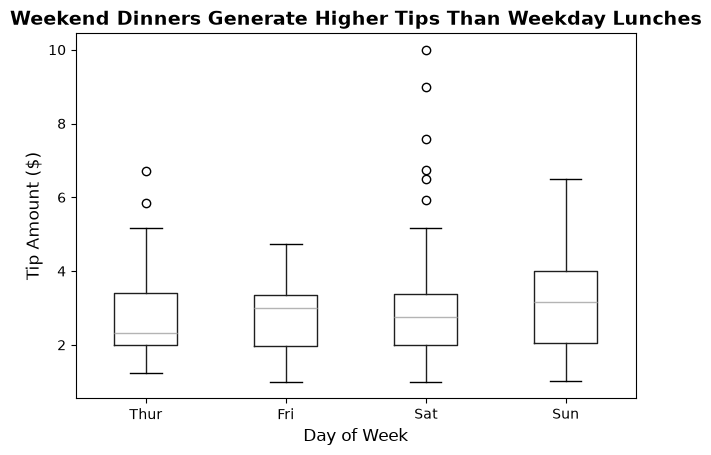

In [10]:
print("=" * 60)
print("TASK 5: EXPLORATORY VISUALIZATION")
print("=" * 60)

# Chart 1: Box plot - Tips by day
plt.figure(figsize=(10, 6))

# Create box plot
df.boxplot(column='tip', by='day', grid=False)
plt.title('Weekend Dinners Generate Higher Tips Than Weekday Lunches', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Tip Amount ($)', fontsize=12)
plt.suptitle('')  # Remove automatic title
plt.tight_layout()

# Save the chart
plt.savefig('../reports/figures/a2_chart1.png', dpi=150, bbox_inches='tight')
print(" Chart 1 saved: reports/figures/a2_chart1.png")
plt.show()

 Chart 2 saved: reports/figures/a2_chart2.png


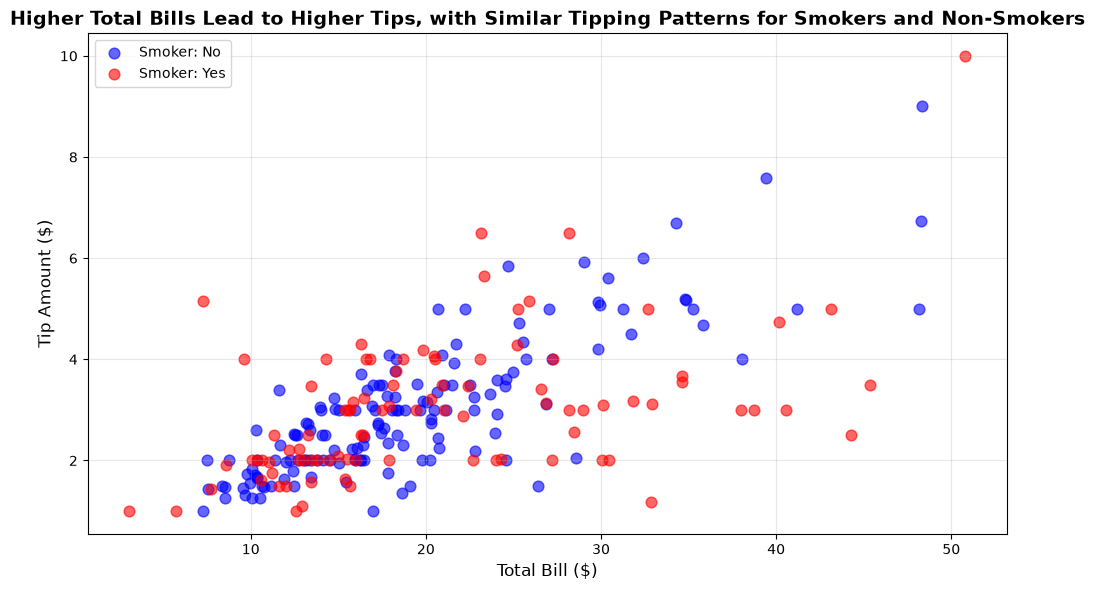


 Both charts saved successfully!


In [11]:
# Chart 2: Scatter plot - Total bill vs Tip, colored by smoking status
plt.figure(figsize=(10, 6))

# Create scatter plot with color differentiation
colors = {'Yes': 'red', 'No': 'blue'}
for smoker in df['smoker'].unique():
    subset = df[df['smoker'] == smoker]
    plt.scatter(subset['total_bill'], subset['tip'], 
               label=f'Smoker: {smoker}', 
               alpha=0.6, 
               s=60,
               color=colors[smoker])

plt.title('Higher Total Bills Lead to Higher Tips, with Similar Tipping Patterns for Smokers and Non-Smokers', 
          fontsize=14, fontweight='bold')
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Tip Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the chart
plt.savefig('../reports/figures/a2_chart2.png', dpi=150, bbox_inches='tight')
print(" Chart 2 saved: reports/figures/a2_chart2.png")
plt.show()

print("\n Both charts saved successfully!")

In [12]:
print("=" * 60)
print("TASK 6: SAVE CLEANED DATASET")
print("=" * 60)

# Save the cleaned and feature-engineered dataset
df.to_csv('../data/processed/cleaned_tips.csv', index=False)

print(" Cleaned dataset saved to: data/processed/cleaned_tips.csv")
print(f"   Shape: {df.shape}")
print(f"   Columns: {len(df.columns)} columns")
print("\n Final column list:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

TASK 6: SAVE CLEANED DATASET
 Cleaned dataset saved to: data/processed/cleaned_tips.csv
   Shape: (243, 15)
   Columns: 15 columns

 Final column list:
   1. total_bill
   2. tip
   3. sex
   4. smoker
   5. day
   6. time
   7. size
   8. avg_tip
   9. max_tip
   10. avg_bill
   11. total_bills_by_day
   12. avg_tip_by_sex
   13. avg_tip_by_smoker
   14. tip_zscore
   15. tip_percentage


In [13]:
print("=" * 60)
print("FINAL SUMMARY - ASSIGNMENT 2 COMPLETED")
print("=" * 60)

print("\n Dataset Information:")
print(f"   Original shape: (244, 7)")
print(f"   Final shape: {df.shape}")
print(f"   Total columns: {len(df.columns)}")
print(f"   New columns added: 5")

print("\n Key Findings:")
print(f"   Average tip: ${df['tip'].mean():.2f}")
print(f"   Average total bill: ${df['total_bill'].mean():.2f}")
print(f"   Average tip percentage: {df['tip_percentage'].mean():.2f}%")

print("\n By Gender:")
print(df.groupby('sex')['tip'].agg(['mean', 'count']))

print("\n By Day:")
print(df.groupby('day')['tip'].agg(['mean', 'count']))

print("\n By Smoker Status:")
print(df.groupby('smoker')['tip'].agg(['mean', 'count']))

print("\n" + "=" * 60)
print(" ASSIGNMENT 2 COMPLETED SUCCESSFULLY!")
print("=" * 60)

# Show final dataframe preview
print("\n Final dataframe preview:")
df.head()

FINAL SUMMARY - ASSIGNMENT 2 COMPLETED

 Dataset Information:
   Original shape: (244, 7)
   Final shape: (243, 15)
   Total columns: 15
   New columns added: 5

 Key Findings:
   Average tip: $3.00
   Average total bill: $19.81
   Average tip percentage: 16.08%

 By Gender:
            mean  count
sex                    
Male    3.089618    157
Female  2.843140     86

 By Day:
          mean  count
day                  
Thur  2.784098     61
Fri   2.734737     19
Sat   2.993103     87
Sun   3.255132     76

 By Smoker Status:
            mean  count
smoker                 
Yes     3.019674     92
No      2.991854    151

 ASSIGNMENT 2 COMPLETED SUCCESSFULLY!

 Final dataframe preview:


,total_bill,tip,sex,smoker,day,time,size,avg_tip,max_tip,avg_bill,total_bills_by_day,avg_tip_by_sex,avg_tip_by_smoker,tip_zscore,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,3.26,6.5,21.41,1627.16,2.843140,2.991854,-1.441513,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,3.26,6.5,21.41,1627.16,3.089618,2.991854,-0.971231,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,3.26,6.5,21.41,1627.16,3.089618,2.991854,0.360029,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,3.26,6.5,21.41,1627.16,3.089618,2.991854,0.222561,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,3.26,6.5,21.41,1627.16,2.843140,2.991854,0.439615,14.680765
